*IMPORT STUFF*

In [282]:
import argparse
import numpy as np
import matplotlib.pyplot as plt
import os
import logging
import ast
import pandas as pd

*LOAD DATA*

Read off the metadata from the first line

In [283]:
def load_run(csv_path):
    # read params from first line
    with open(csv_path, "r") as f:
        first_line = f.readline()
        params = ast.literal_eval(
            first_line.replace("# params: ", "").strip()
        )

    # load data (skip first line)
    data = pd.read_csv(csv_path, comment="#")

    return data, params


In [ ]:
FILE_DIR = "../code/SAVED_HERE/"

# FILES = [
#     "phi_k100_b1.22.csv",
#     "phi_k150_b1.22.csv",
#     "phi_k200_b1.22.csv",
#     "phi_k250_b1.22.csv",
#     "phi_k300_b1.22.csv",
#     "phi_k200_b1.csv",
#     "phi_k200_b1.1.csv",
#     "phi_k200_b1.2.csv",
#     "phi_k200_b1.3.csv",
#     "phi_k200_b1.4.csv",
# ]

FILES = [
    "phi_k200_b1.2.csv",
]


In [285]:
def phi_of_N(N, b, kappa, N_end):
    inside = (kappa / b**2) * (N_end - N) + kappa / (b * np.sqrt(2))
    return -b * np.log(inside)

In [286]:
def phi_prime_from_phi(phi, b, kappa):
    return (kappa / b) * np.exp(phi / b)

In [287]:
# def phi_kination(N, b, kappa):
#     return np.sqrt(2 * kappa) * N + b * 0.5 * np.log((2 * b**2) / kappa) 

In [288]:
def phi_kination(N, phi_0, phi_prime_0, N_end):
    return phi_prime_0 * (N-N_end) + phi_0

In [289]:
b_analytic = 1.2
kappa_analytic = 200
N_end_analytic = 20.0
N_end_kination = 23.0
N_start_kination = 21.0

N_analytic = np.linspace(0.0, N_end_analytic, 10000)

*PLOT*

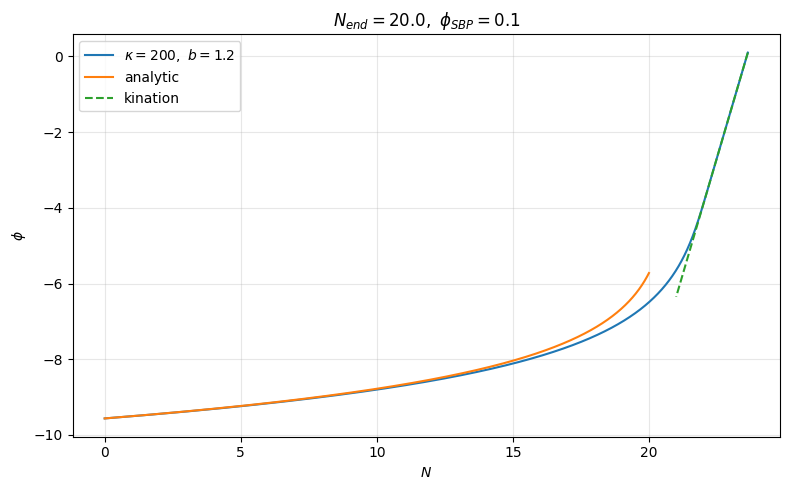

In [290]:
plt.figure(figsize=(8, 5))

for fname in FILES:
    data, params = load_run(FILE_DIR + fname)

    x = data["N"]
    y = data["phi"]
    y_prime = data["phi_prime"]

    label = rf"$\kappa={params['kappa']},\ b={params['b']}$"
    plt.plot(x, y, label=label)

phi_analitic = phi_of_N(N_analytic, b_analytic, kappa_analytic, N_end_analytic)
phi_prime_analytic = phi_prime_from_phi(phi_analitic, b_analytic, kappa_analytic)

# phi_kination_analytic = phi_kination(N_kination, b_analytic, kappa_analytic)

# phi_kination_analytic = phi_kination(N_kination, phi_analitic[-1], phi_prime_analytic[-1], N_end_analytic)
# phi_kination_analytic = phi_kination(N_kination, y.iloc[-1], y_prime.iloc[-1], x.iloc[-1])
N_kination = np.linspace(x.iloc[-1], N_start_kination, 1000 )
phi_kination_analytic = phi_kination(N_kination, y.iloc[-1], np.sqrt(6), x.iloc[-1])
phi_prime_kination_analytic = np.full(1000, np.sqrt(6))

plt.plot(N_analytic, phi_analitic, label="analytic")
plt.plot(N_kination, phi_kination_analytic, label="kination", linestyle="--")
plt.title(
    rf"$N_{{end}}={params['N_end']},\ \phi_{{SBP}}={params['phi_sbp']}$"
)
plt.xlabel(r"$N$")
plt.ylabel(r"$\phi$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [291]:
# def phi_of_N(N, phi_i, kappa, b):
#     return -b * np.log(
#         np.exp(-phi_i / b) + (kappa / b**2) * N
#     )

# def phi_of_N_v2(N, phi_i, kappa, b):
#     return -b * np.log((kappa / b**2) * N)

In [292]:
# print(x)

In [293]:
# analytic_phi = phi_of_N(x, 1.0, 1.0, 1.0)

# # analytic_phi = analytic_phi + 1

# plt.plot(x, analytic_phi, label="analytic")

# plt.plot(x, y, label="numerical")

# plt.title(r"Slowrol with $\kappa = 1$, $b=1.0$, $\phi_i = 1.0$, $N \in [0;60]$")
# plt.xlabel(r"$N$")
# plt.ylabel(r"$\phi$")
# # plt.yscale(value="log")
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

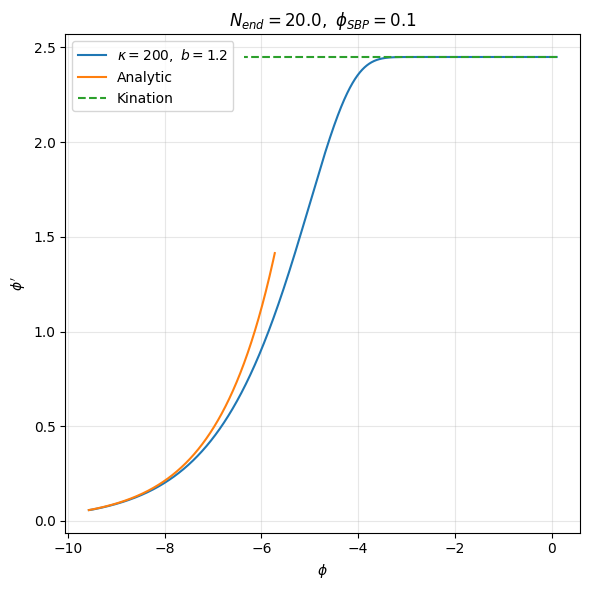

In [294]:
plt.figure(figsize=(6, 6))

for fname in FILES:
    data, params = load_run(FILE_DIR + fname)

    phi = data["phi"]
    phi_p = data["phi_prime"]

    label = rf"$\kappa={params['kappa']},\ b={params['b']}$"
    plt.plot(phi, phi_p, label=label)

plt.title(
    rf"$N_{{end}}={params['N_end']},\ \phi_{{SBP}}={params['phi_sbp']}$"
)

plt.plot(phi_analitic, phi_prime_analytic, label="Analytic")
plt.plot(phi_kination_analytic, phi_prime_kination_analytic, label="Kination", linestyle="--")

plt.xlabel(r"$\phi$")
plt.ylabel(r"$\phi'$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
